In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

os.chdir(r'C:\Users\aruna\Desktop\Work\MLDAY1')
df = pd.read_csv('heart.csv')
print(df.shape)
print(df.head(5))
print(df.info())

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

In [5]:
print(df.isnull().sum().sort_values(ascending=False))
print(df.duplicated().sum())
print(df.info())
print(df.describe())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
723
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
         

In [8]:
df=df.drop_duplicates()
print(df.shape)

(302, 14)


<Axes: xlabel='target', ylabel='Count'>

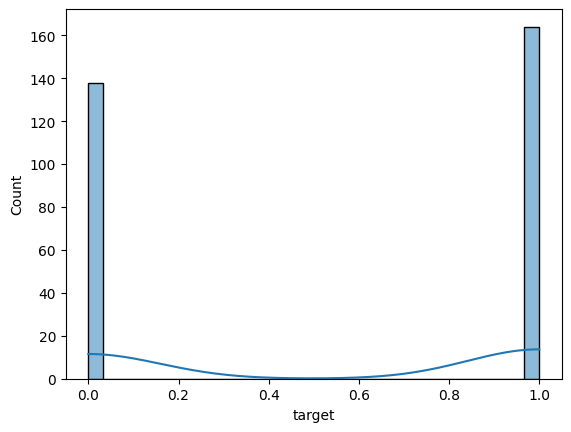

In [9]:
sns.histplot(df['target'].dropna(),bins=30,kde=True)

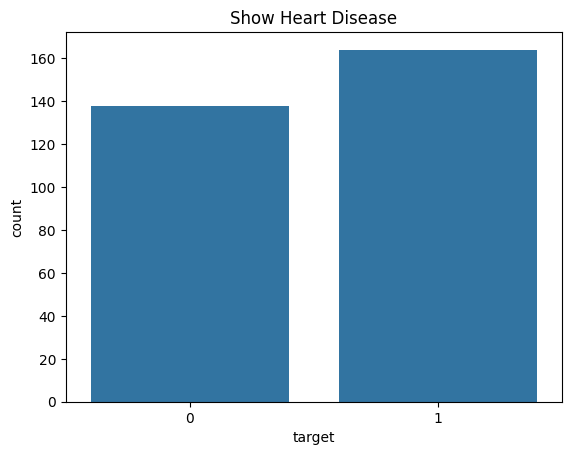

In [10]:
sns.countplot(x='target',data=df)
plt.title('Show Heart Disease')
plt.show()


In [11]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)  # percentage

target
1    164
0    138
Name: count, dtype: int64
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


<Axes: >

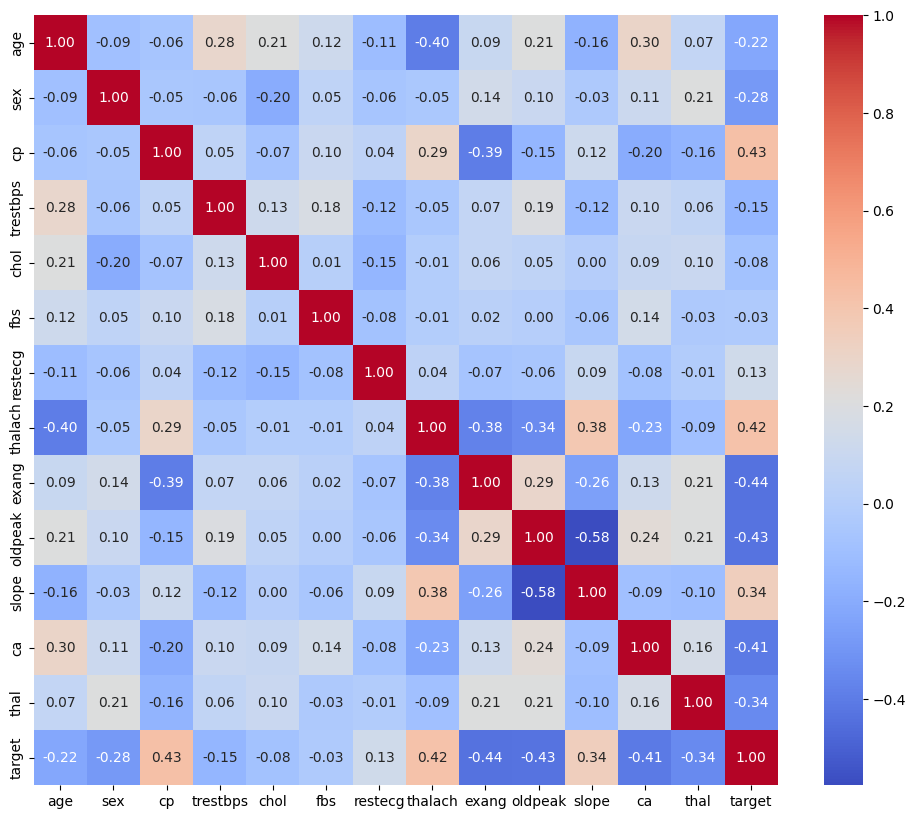

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')



In [18]:
correlation=df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlation)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


In [19]:
print((df['exang'].value_counts()))

exang
0    203
1     99
Name: count, dtype: int64


In [22]:
print(df.groupby('exang')['target'].mean())
df['target'] = 1 - df['target']
df['target'] = 1 - df['target']
print(df.groupby('exang')['target'].mean())

exang
0    0.305419
1    0.767677
Name: target, dtype: float64
exang
0    0.305419
1    0.767677
Name: target, dtype: float64


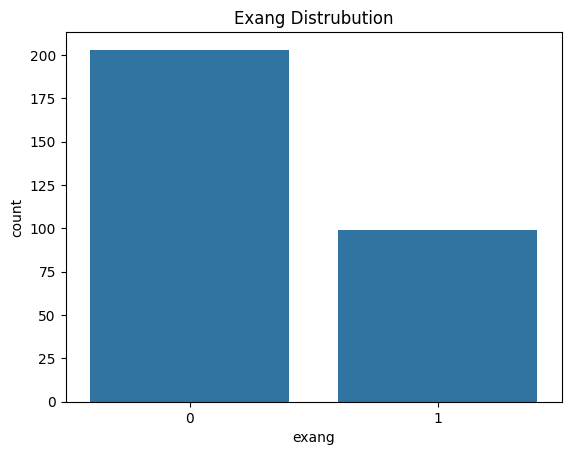

In [24]:
sns.countplot(x='exang',data=df)
plt.title('Exang Distrubution')
plt.show()

<Axes: xlabel='age', ylabel='Count'>

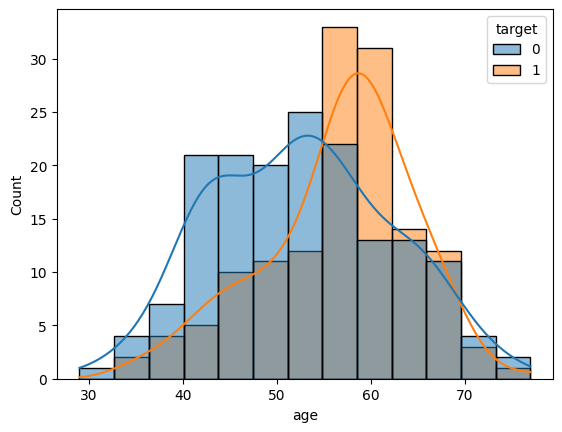

In [29]:
sns.histplot(data=df, x='age', hue='target', kde=True)


<Axes: xlabel='target', ylabel='count'>

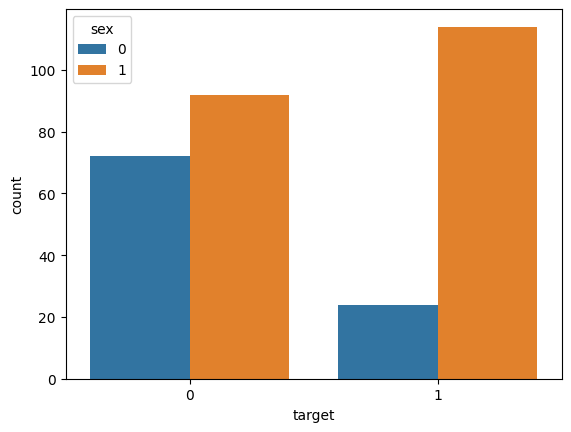

In [27]:
sns.countplot(x='target', hue='sex', data=df)

<Axes: xlabel='target', ylabel='oldpeak'>

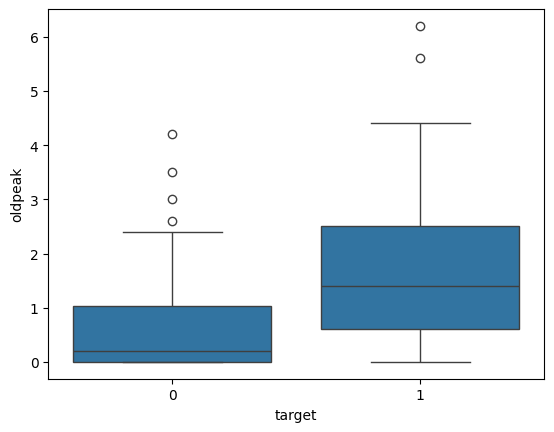

In [31]:
sns.boxplot(x='target', y='oldpeak', data=df)


In [32]:
print(df.groupby('sex')['target'].mean())
print(df.groupby('cp')['target'].mean())

sex
0    0.250000
1    0.553398
Name: target, dtype: float64
cp
0    0.727273
1    0.180000
2    0.209302
3    0.304348
Name: target, dtype: float64


In [33]:
df.to_csv('Heart-Cleaned.csv', index=False)
print("saved")
print(df.shape)

saved
(302, 14)
